In [ ]:
import pandas as pd
import numpy as np

df_clean = pd.read_csv("../data/processed/HHS_Clean_Dataset.csv")
df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean = df_clean.sort_values("Date")
df_clean = df_clean.set_index("Date")

series = df_clean["Children in HHS Care"]
train_size = int(len(series) * 0.8)
train = series[:train_size]
test = series[train_size:]

In [2]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

hw_fit = hw_model.fit()

hw_forecast = hw_fit.forecast(steps=len(test))
hw_forecast.index = test.index

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(test, hw_forecast)
rmse = np.sqrt(mean_squared_error(test, hw_forecast))
mape = mean_absolute_percentage_error(test, hw_forecast)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape*100:.2f}%")

MAE  : 843.79
RMSE : 939.78
MAPE : 38.32%


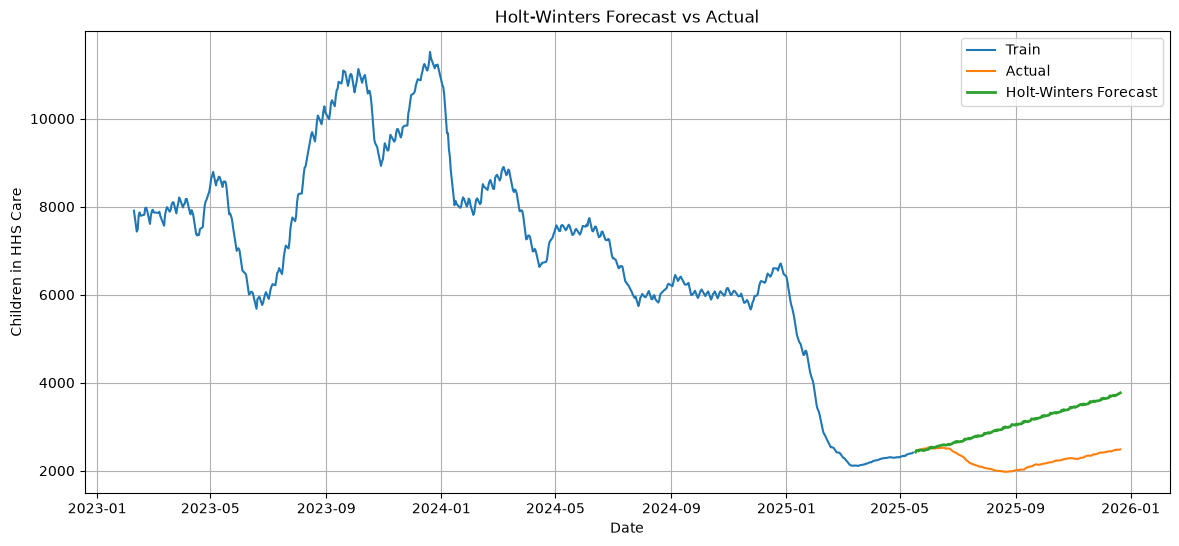

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, hw_forecast, label="Holt-Winters Forecast", linewidth=2)

plt.title("Holt-Winters Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(True)

plt.show()